# 🌤️ Weather Image Recognition — ML Pipeline
**Etape 02 — Notebook Python**

Ce notebook lit le fichier Parquet produit par le Microservice 1 (Scala) et entraîne **3 modèles** :
1. `Random Forest / SVM` (ML classique)
2. `CNN` (réseau de neurones convolutif)
3. `Transfer Learning` (ResNet50 pré-entraîné)

## Les imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import warnings
warnings.filterwarnings('ignore')


from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

##  Chargement du fichier Parquet

In [3]:
PARQUET_PATH = r"C:\spark-data\output\weather.parquet"

table = pq.read_table(PARQUET_PATH)
df = table.to_pandas()

print(f"Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(df.head())
print(df.columns)

Données chargées : 6862 lignes, 8 colonnes
                            imagePath  fileName label  labelId  width  height  \
0  C:\spark-data\dataset\dew\2808.jpg  2808.jpg   dew        0     64      64   
1  C:\spark-data\dataset\dew\2809.jpg  2809.jpg   dew        0     64      64   
2  C:\spark-data\dataset\dew\2810.jpg  2810.jpg   dew        0     64      64   
3  C:\spark-data\dataset\dew\2811.jpg  2811.jpg   dew        0     64      64   
4  C:\spark-data\dataset\dew\2812.jpg  2812.jpg   dew        0     64      64   

   channels                                           features  
0         3  [0.31764707, 0.49019608, 0.16078432, 0.2980392...  
1         3  [0.99215686, 0.9843137, 0.85882354, 0.9843137,...  
2         3  [0.047058824, 0.047058824, 0.039215688, 0.0549...  
3         3  [0.105882354, 0.41960785, 0.07058824, 0.121568...  
4         3  [0.12941177, 0.2, 0.29411766, 0.13333334, 0.20...  
Index(['imagePath', 'fileName', 'label', 'labelId', 'width', 'height',
       'c

## Exploration des données 

EXPLORATION DES DONNÉES

 Labels uniques : <ArrowStringArray>
[      'dew',   'fogsmog', 'sandstorm',     'glaze',     'frost',      'rime',
      'snow',      'rain',      'hail',   'rainbow', 'lightning']
Length: 11, dtype: str

 Dimensions images : [64] x [64]
Canaux : [3]

Taille du vecteur features : 12288


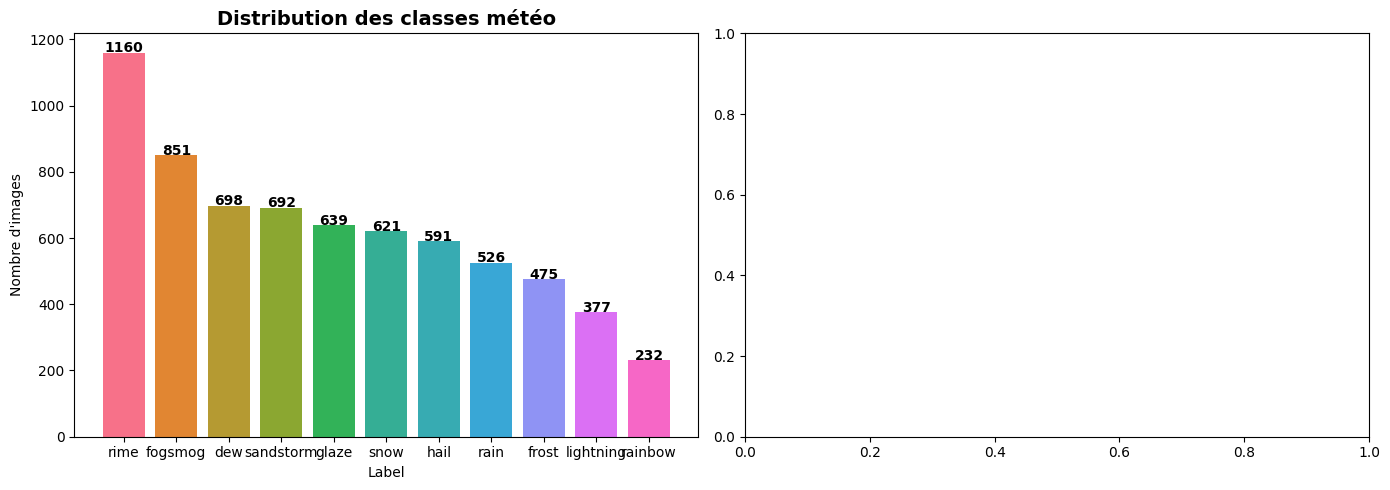

Graphique sauvegardé : eda_distribution.png


In [4]:
print("=" * 50)
print("EXPLORATION DES DONNÉES")
print("=" * 50)

print(f"\n Labels uniques : {df['label'].unique()}")
print(f"\n Dimensions images : {df['width'].unique()} x {df['height'].unique()}")
print(f"Canaux : {df['channels'].unique()}")
print(f"\nTaille du vecteur features : {len(df['features'].iloc[0])}")

# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart des classes
label_counts = df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('husl', len(label_counts)))
axes[0].set_title('Distribution des classes météo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Nombre d\'images')
for i, (k, v) in enumerate(label_counts.items()):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')



plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : eda_distribution.png")

## Préparation des données — Train / Validation / Test Split

In [5]:
# ── Extraction des features et labels ──
X = np.array(df['features'].tolist(), dtype=np.float32)  # (N, W*H*C)
y = df['labelId'].values                                   # entiers
label_names = df.groupby('labelId')['label'].first().sort_index().values

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"Mapping labels : {dict(enumerate(label_names))}")

# ── Split 70% train / 15% val / 15% test ──
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 ≈ 15% du total
)

print(f"\n Split :")
print(f"   Train      : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation : {X_val.shape[0]}   ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test       : {X_test.shape[0]}   ({X_test.shape[0]/len(X)*100:.1f}%)")

# ── Normalisation pour ML classique ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ── Reshape pour CNN / Transfer Learning ──
IMG_HEIGHT = int(df['height'].iloc[0])
IMG_WIDTH  = int(df['width'].iloc[0])
CHANNELS   = int(df['channels'].iloc[0])
NUM_CLASSES = len(label_names)

X_train_img = X_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)
X_val_img   = X_val.reshape(-1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)
X_test_img  = X_test.reshape(-1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)

# One-hot pour Keras
y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_cat   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"\n Shape images CNN : {X_train_img.shape}")

Shape X : (6862, 12288)
Shape y : (6862,)
Mapping labels : {0: 'dew', 1: 'fogsmog', 2: 'frost', 3: 'glaze', 4: 'hail', 5: 'lightning', 6: 'rain', 7: 'rainbow', 8: 'rime', 9: 'sandstorm', 10: 'snow'}

 Split :
   Train      : 4805 (70.0%)
   Validation : 1027   (15.0%)
   Test       : 1030   (15.0%)

 Shape images CNN : (4805, 64, 64, 3)


---
## MODÈLE 1 — Random Forest & SVM (ML Classique)
> Utilise PCA pour réduire la dimensionnalité avant le SVM

In [6]:
print("=" * 55)
print("MODÈLE 1 — Random Forest")
print("=" * 55)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train_scaled, y_train)

rf_val_acc  = accuracy_score(y_val,  rf_model.predict(X_val_scaled))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test_scaled))
rf_preds    = rf_model.predict(X_test_scaled)

print(f"\n Val Accuracy  : {rf_val_acc:.4f}")
print(f"Test Accuracy : {rf_test_acc:.4f}")
print("\n Rapport de classification :")
print(classification_report(y_test, rf_preds, target_names=label_names))

MODÈLE 1 — Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   10.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s



 Val Accuracy  : 0.6115
Test Accuracy : 0.6340

 Rapport de classification :
              precision    recall  f1-score   support

         dew       0.70      0.74      0.72       105
     fogsmog       0.70      0.84      0.76       128
       frost       0.56      0.25      0.35        71
       glaze       0.59      0.56      0.58        96
        hail       0.55      0.53      0.54        89
   lightning       0.76      0.75      0.76        56
        rain       0.50      0.39      0.44        79
     rainbow       0.90      0.26      0.40        35
        rime       0.63      0.77      0.69       174
   sandstorm       0.70      0.75      0.73       104
        snow       0.52      0.59      0.55        93

    accuracy                           0.63      1030
   macro avg       0.65      0.58      0.59      1030
weighted avg       0.63      0.63      0.62      1030



[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


In [7]:
print("=" * 55)
print(" MODÈLE 1b — SVM (avec PCA)")
print("=" * 55)

# PCA pour accélérer le SVM
n_components = min(150, X_train_scaled.shape[1])
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

explained = pca.explained_variance_ratio_.sum()
print(f" PCA : {n_components} composantes → {explained*100:.1f}% variance expliquée")

svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train)

svm_val_acc  = accuracy_score(y_val,  svm_model.predict(X_val_pca))
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test_pca))
svm_preds    = svm_model.predict(X_test_pca)

print(f"\n Val Accuracy  : {svm_val_acc:.4f}")
print(f" Test Accuracy : {svm_test_acc:.4f}")
print("\n Rapport de classification :")
print(classification_report(y_test, svm_preds, target_names=label_names))

 MODÈLE 1b — SVM (avec PCA)
 PCA : 150 composantes → 89.1% variance expliquée

 Val Accuracy  : 0.6173
 Test Accuracy : 0.6437

 Rapport de classification :
              precision    recall  f1-score   support

         dew       0.72      0.76      0.74       105
     fogsmog       0.67      0.88      0.76       128
       frost       0.37      0.20      0.26        71
       glaze       0.57      0.56      0.57        96
        hail       0.60      0.55      0.58        89
   lightning       0.66      0.82      0.73        56
        rain       0.48      0.46      0.47        79
     rainbow       0.67      0.34      0.45        35
        rime       0.68      0.70      0.69       174
   sandstorm       0.81      0.81      0.81       104
        snow       0.59      0.59      0.59        93

    accuracy                           0.64      1030
   macro avg       0.62      0.61      0.60      1030
weighted avg       0.63      0.64      0.63      1030



---
## MODÈLE 2 — CNN (Réseau de neurones convolutif)

In [8]:
print("=" * 55)
print("MODÈLE 2 — CNN")
print("=" * 55)

def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        # Bloc 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloc 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloc 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.40),

        # Tête de classification
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.50),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn((IMG_HEIGHT, IMG_WIDTH, CHANNELS), NUM_CLASSES)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

MODÈLE 2 — CNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,240,555 (8.55 MB)

 Trainable params: 2,240,107 (8.55 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# Data Augmentation pour le CNN
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
])

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

cnn_history = cnn_model.fit(
    X_train_img, y_train_cat,
    validation_data=(X_val_img, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_cnn,
    verbose=1
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_img, y_test_cat, verbose=0)
cnn_preds = np.argmax(cnn_model.predict(X_test_img), axis=1)

print(f"\nTest Accuracy CNN : {cnn_test_acc:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, cnn_preds, target_names=label_names))

Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 28s 160ms/step - accuracy: 0.4216 - loss: 2.1087 - val_accuracy: 0.1840 - val_loss: 11.1679 - learning_rate: 0.0010
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.4995 - loss: 1.5260 - val_accuracy: 0.1441 - val_loss: 11.6729 - learning_rate: 0.0010
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 156ms/step - accuracy: 0.5188 - loss: 1.4710 - val_accuracy: 0.4693 - val_loss: 3.2822 - learning_rate: 0.0010
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 154ms/step - accuracy: 0.5315 - loss: 1.4079 - val_accuracy: 0.5589 - val_loss: 1.9540 - learning_rate: 0.0010
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.5632 - loss: 1.2960 - val_accuracy: 0.2678 - val_loss: 4.8519 - learning_rate: 0.0010
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.5686 - loss: 1.2767 - val_accuracy: 0.4703 - val_loss: 3.3272 - learning_rate: 0.0010
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step - accuracy: 0

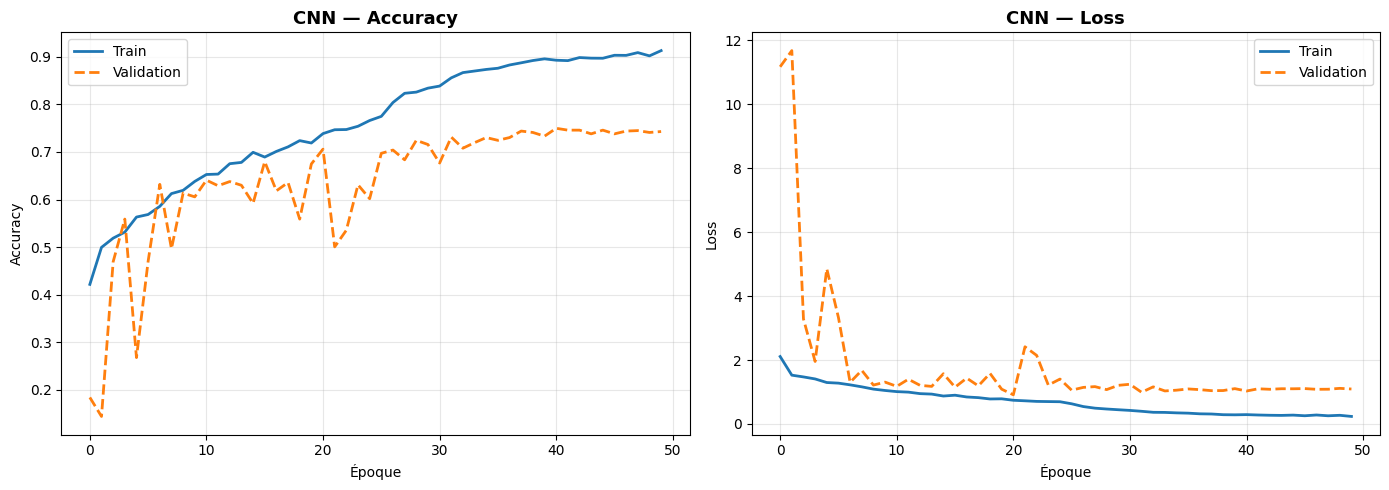

In [10]:
# Courbes d'apprentissage CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['accuracy'],    label='Train', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('CNN — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cnn_history.history['loss'],    label='Train', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[1].set_title('CNN — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  MODÈLE 3 — Transfer Learning (ResNet50)

In [11]:
print("=" * 55)
print(" MODÈLE 3 — Transfer Learning (ResNet50)")
print("=" * 55)

# ResNet50 attend des images RGB 224x224 minimum
TARGET_SIZE = (224, 224)

def resize_dataset(X_img):
    """Redimensionne et adapte pour ResNet50 (RGB 224x224)"""
    import tensorflow as tf
    X_resized = tf.image.resize(X_img, TARGET_SIZE).numpy()
    # Si grayscale, convertir en RGB
    if X_resized.shape[-1] == 1:
        X_resized = np.concatenate([X_resized] * 3, axis=-1)
    # Préprocessing ResNet50
    return keras.applications.resnet50.preprocess_input(X_resized * 255.0)

print("Redimensionnement des images pour ResNet50...")
X_train_rn = resize_dataset(X_train_img)
X_val_rn   = resize_dataset(X_val_img)
X_test_rn  = resize_dataset(X_test_img)
print(f" Shape : {X_train_rn.shape}")

 MODÈLE 3 — Transfer Learning (ResNet50)
Redimensionnement des images pour ResNet50...
 Shape : (4805, 224, 224, 3)


In [12]:
# Construire le modèle Transfer Learning
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Phase 1 : feature extraction seulement

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = keras.Model(inputs, outputs)
resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Paramètres entraînables : {resnet_model.count_params():,}")
print(f"Paramètres figés (ResNet50) : {base_model.count_params():,}")

Paramètres entraînables : 24,115,083
Paramètres figés (ResNet50) : 23,587,712


In [13]:
callbacks_rn = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

# Phase 1 : Feature Extraction
print("Phase 1 : Feature Extraction (ResNet figé)")
rn_history1 = resnet_model.fit(
    X_train_rn, y_train_cat,
    validation_data=(X_val_rn, y_val_cat),
    epochs=20,
    batch_size=16,
    callbacks=callbacks_rn,
    verbose=1
)

# Phase 2 : Fine-tuning (dégeler les 30 dernières couches)
print("\nPhase 2 : Fine-tuning (30 dernières couches)")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # LR très faible pour fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rn_history2 = resnet_model.fit(
    X_train_rn, y_train_cat,
    validation_data=(X_val_rn, y_val_cat),
    epochs=20,
    batch_size=16,
    callbacks=callbacks_rn,
    verbose=1
)

rn_test_loss, rn_test_acc = resnet_model.evaluate(X_test_rn, y_test_cat, verbose=0)
rn_preds = np.argmax(resnet_model.predict(X_test_rn), axis=1)

print(f"\n Test Accuracy ResNet50 : {rn_test_acc:.4f}")
print("\n Rapport de classification :")
print(classification_report(y_test, rn_preds, target_names=label_names))

Phase 1 : Feature Extraction (ResNet figé)
Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.7228 - loss: 0.8463 - val_accuracy: 0.8169 - val_loss: 0.5050 - learning_rate: 0.0010
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8360 - loss: 0.4874 - val_accuracy: 0.8423 - val_loss: 0.4690 - learning_rate: 0.0010
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1513s 5s/step - accuracy: 0.8710 - loss: 0.3833 - val_accuracy: 0.8510 - val_loss: 0.4171 - learning_rate: 0.0010
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 258s 859ms/step - accuracy: 0.8799 - loss: 0.3432 - val_accuracy: 0.8462 - val_loss: 0.4446 - learning_rate: 0.0010
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 277s 920ms/step - accuracy: 0.8995 - loss: 0.2859 - val_accuracy: 0.8734 - val_loss: 0.4153 - learning_rate: 0.0010
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.9088 - loss: 0.2584 - val_accuracy: 0.8588 - val_loss: 0.4239 - learning_rate: 0.0010
Epoch 7/20
301/301 ━━━━━━━━━━━━━

---
## Comparaison des Modèles & Matrices de Confusion


 CLASSEMENT DES MODÈLES
             Modèle  Test Accuracy  Rang
ResNet50 (Transfer)         0.8932     1
                CNN         0.7806     2
        SVM (+ PCA)         0.6437     3
      Random Forest         0.6340     4


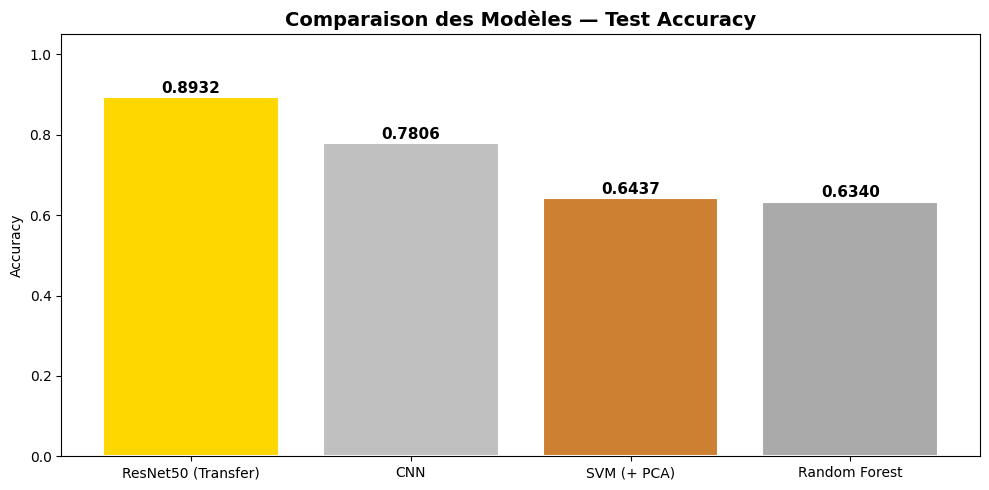

In [14]:
# ── Tableau récapitulatif ──
results = pd.DataFrame({
    'Modèle': ['Random Forest', 'SVM (+ PCA)', 'CNN', 'ResNet50 (Transfer)'],
    'Test Accuracy': [
        round(rf_test_acc, 4),
        round(svm_test_acc, 4),
        round(cnn_test_acc, 4),
        round(rn_test_acc, 4)
    ]
}).sort_values('Test Accuracy', ascending=False)

results['Rang'] = range(1, len(results) + 1)
print("\n CLASSEMENT DES MODÈLES")
print(results.to_string(index=False))

# Bar chart comparatif
colors = ['gold', 'silver', '#cd7f32', '#aaaaaa']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results['Modèle'], results['Test Accuracy'],
              color=colors[:len(results)], edgecolor='white', linewidth=1.5)
ax.set_ylim(0, 1.05)
ax.set_title('Comparaison des Modèles — Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, results['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

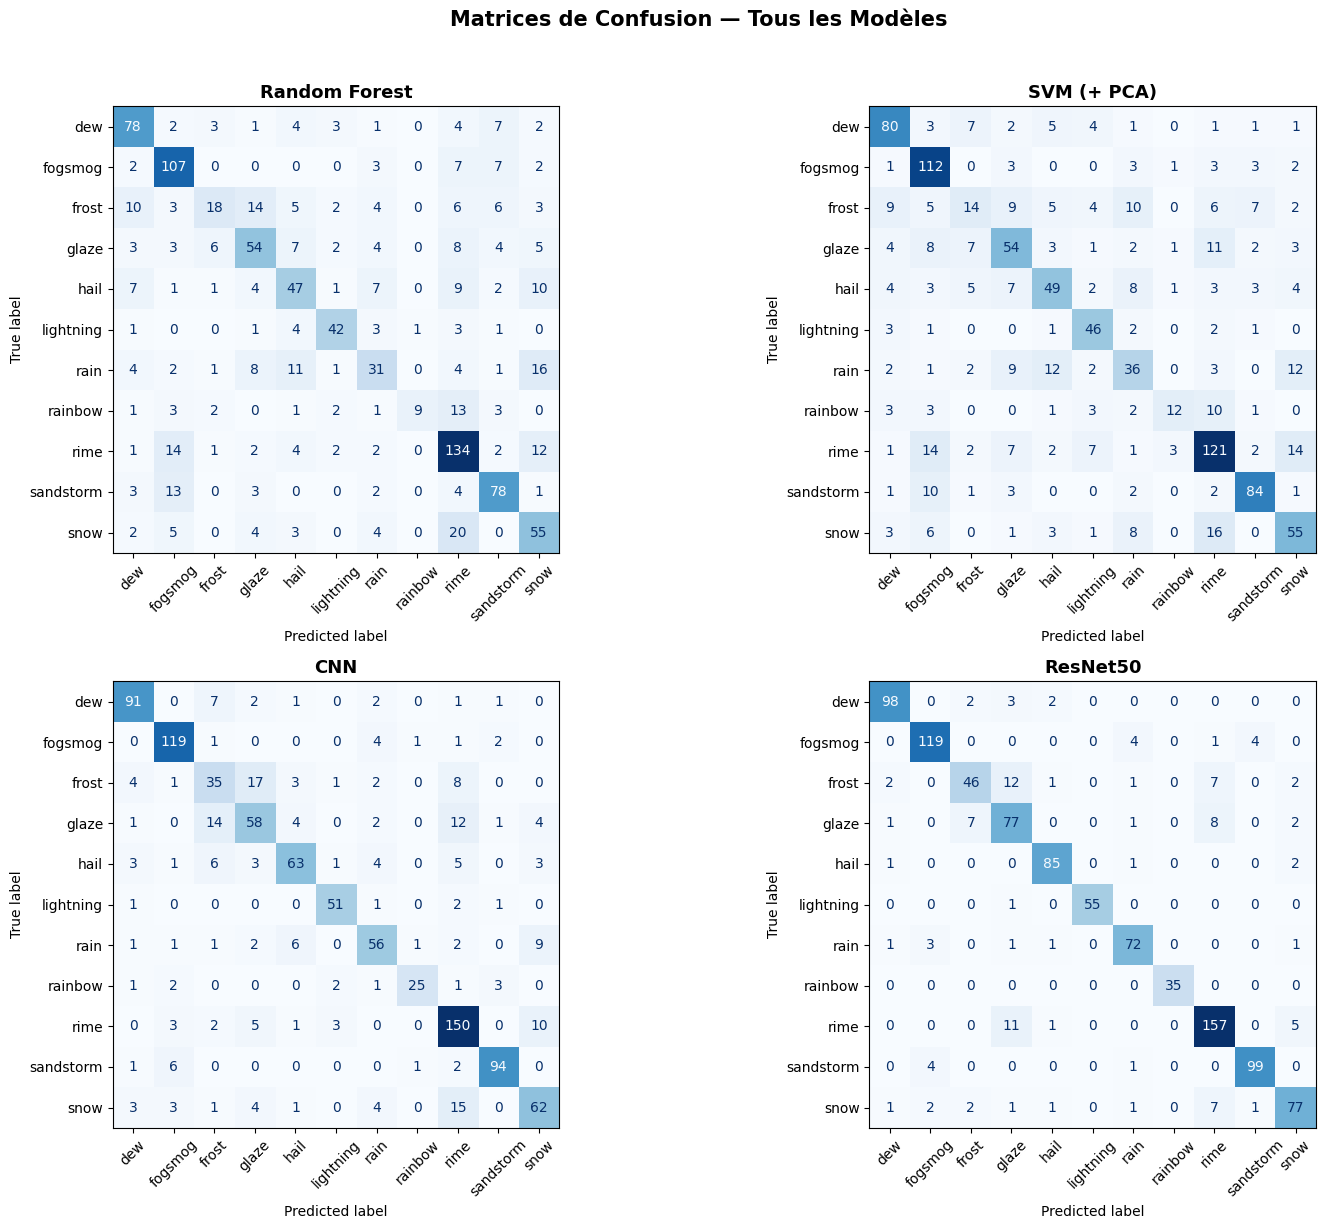

 Graphiques sauvegardés.


In [15]:
# ── Matrices de confusion ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

models_info = [
    ('Random Forest', rf_preds),
    ('SVM (+ PCA)',   svm_preds),
    ('CNN',           cnn_preds),
    ('ResNet50',      rn_preds)
]

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Matrices de Confusion — Tous les Modèles', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphiques sauvegardés.")

---
## Sauvegarde des Modèles

In [16]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

# ML classique → joblib
joblib.dump(rf_model,  'saved_models/random_forest.joblib')
joblib.dump(svm_model, 'saved_models/svm.joblib')
joblib.dump(scaler,    'saved_models/scaler.joblib')
joblib.dump(pca,       'saved_models/pca.joblib')

# Keras → SavedModel
cnn_model.save('saved_models/cnn_model.keras')
resnet_model.save('saved_models/resnet50_model.keras')

print("Tous les modèles sauvegardés dans saved_models/")
for f in os.listdir('saved_models'):
    print(f"  {f}")

Tous les modèles sauvegardés dans saved_models/
  cnn_model.keras
  pca.joblib
  random_forest.joblib
  resnet50_model.keras
  scaler.joblib
  svm.joblib


---
## Prédiction sur une nouvelle image (inférence)

In [17]:
def predict_weather(features_vector: list, model_choice: str = 'resnet') -> dict:
    """
    Prédit la classe météo à partir d'un vecteur de features.
    
    Args:
        features_vector : liste de floats (sortie du Microservice 1)
        model_choice    : 'rf', 'svm', 'cnn', 'resnet'
    Returns:
        dict avec label prédit et probabilités
    """
    x = np.array(features_vector, dtype=np.float32).reshape(1, -1)

    if model_choice == 'rf':
        x_s = scaler.transform(x)
        pred = rf_model.predict(x_s)[0]
        proba = rf_model.predict_proba(x_s)[0]

    elif model_choice == 'svm':
        x_s = scaler.transform(x)
        x_p = pca.transform(x_s)
        pred = svm_model.predict(x_p)[0]
        proba = svm_model.predict_proba(x_p)[0]

    elif model_choice == 'cnn':
        x_img = x.reshape(1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)
        proba = cnn_model.predict(x_img, verbose=0)[0]
        pred = np.argmax(proba)

    elif model_choice == 'resnet':
        x_img = x.reshape(1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)
        x_rn = resize_dataset(x_img)
        proba = resnet_model.predict(x_rn, verbose=0)[0]
        pred = np.argmax(proba)

    return {
        'label': label_names[pred],
        'labelId': int(pred),
        'confidence': float(proba[pred]),
        'probabilities': {label_names[i]: float(p) for i, p in enumerate(proba)}
    }

# Test avec un exemple du dataset
sample_features = df['features'].iloc[0]
for m in ['rf', 'svm', 'cnn', 'resnet']:
    result = predict_weather(sample_features, model_choice=m)
    print(f"[{m:6s}] Prédit: {result['label']:12s} | Confiance: {result['confidence']:.2%}")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


[rf    ] Prédit: dew          | Confiance: 99.50%
[svm   ] Prédit: dew          | Confiance: 99.95%
[cnn   ] Prédit: dew          | Confiance: 100.00%
[resnet] Prédit: dew          | Confiance: 100.00%


In [18]:
import tensorflow as tf
import keras
print(tf.__version__)
print(keras.__version__)

2.21.0
3.14.0


---
## Résumé

| Étape | Détail |
|---|---|
| **Source** | Parquet produit par Microservice 1 (Scala) |
| **Features** | Vecteur extrait par `ImagePreprocessor` |
| **Split** | 70% train / 15% val / 15% test |
| **Modèle 1** | Random Forest (200 arbres) + SVM RBF (PCA 150 dim) |
| **Modèle 2** | CNN 3 blocs conv + BatchNorm + Dropout |
| **Modèle 3** | ResNet50 (ImageNet) + Fine-tuning 30 dernières couches |
| **Outputs** | Modèles sauvegardés + graphiques |
